# Are Loyal Customers More Valuable?

Follow-up to `Q2_high_value_customers.ipynb`, which segmented customers by total spend. This
notebook segments by **loyalty** instead — do customers who come back more than once end up
worth more, and if so, by how much, and over what timeframe?

**Setup:** the business already believes repeat customers are "worth more" — the interesting
questions are how much more, whether the value comes from bigger orders or just more of them,
and how fast the gap between a loyal and a one-time customer actually opens up.

We define loyalty two ways:
1. **Repeat vs. one-time** — did the customer ever place a 2nd order?
2. **Loyalty tiers** — 1 / 2 / 3 / 4+ orders, to check the relationship is monotonic and not
   just a step change at "2".


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

plt.rcParams["axes.formatter.useoffset"] = False
plt.rcParams["axes.formatter.limits"] = (-999, 999)

PLAIN = mticker.FuncFormatter(lambda x, pos: f"{x:,.0f}")
PCT = mticker.FuncFormatter(lambda x, pos: f"{x:,.0f}%")
MILLIONS = mticker.FuncFormatter(lambda x, pos: f"{x/1e6:,.0f}")

df = pd.read_csv("orders.csv", parse_dates=["Order_Date"])
df = df.sort_values(["Customer_iD", "Order_Date"])
df.shape


(682792, 11)

## 1. Repeat vs. one-time — how rare is loyalty, and does it pay off?

Aggregate to the customer level. A customer is `Repeat` if they placed 2 or more orders,
`One-time` otherwise.


In [2]:
cust = df.groupby("Customer_iD").agg(
    n_orders=("Order_ID", "size"),
    total_spend=("Total_amount_excl__VAT", "sum"),
    total_profit=("Profit", "sum"),
    avg_margin=("Profit_margin", "mean"),
    first_order=("Order_Date", "min"),
    last_order=("Order_Date", "max"),
)
cust["segment"] = np.where(cust["n_orders"] >= 2, "Repeat (2+ orders)", "One-time (1 order)")

n_customers = len(cust)
seg_counts = cust["segment"].value_counts()
print(f"Customers: {n_customers:,}")
print(seg_counts)
print((seg_counts / n_customers * 100).round(1))


Customers: 577,950
segment
One-time (1 order)    495909
Repeat (2+ orders)     82041
Name: count, dtype: int64
segment
One-time (1 order)    85.8
Repeat (2+ orders)    14.2
Name: count, dtype: float64


In [3]:
seg = cust.groupby("segment").agg(
    n=("n_orders", "size"),
    total_spend=("total_spend", "sum"),
    total_profit=("total_profit", "sum"),
    avg_spend=("total_spend", "mean"),
    avg_profit=("total_profit", "mean"),
    avg_margin=("avg_margin", "mean"),
)
seg["cust_share_%"] = (seg["n"] / seg["n"].sum() * 100).round(1)
seg["spend_share_%"] = (seg["total_spend"] / seg["total_spend"].sum() * 100).round(1)
seg["profit_share_%"] = (seg["total_profit"] / seg["total_profit"].sum() * 100).round(1)
seg[["n", "cust_share_%", "spend_share_%", "profit_share_%", "avg_spend", "avg_profit", "avg_margin"]].round(1)


,n,cust_share_%,spend_share_%,profit_share_%,avg_spend,avg_profit,avg_margin
segment,,,,,,,
One-time (1 order),495909,85.8,72.1,71.8,506.8,316.4,0.6
Repeat (2+ orders),82041,14.2,27.9,28.2,1187.8,749.7,0.6


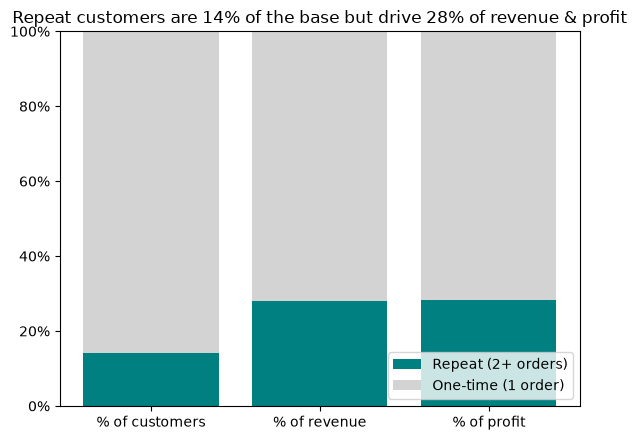

In [4]:
fig, ax = plt.subplots(figsize=(6, 4.5))
metrics = ["cust_share_%", "spend_share_%", "profit_share_%"]
labels = ["% of customers", "% of revenue", "% of profit"]
repeat_vals = [seg.loc["Repeat (2+ orders)", m] for m in metrics]
onetime_vals = [seg.loc["One-time (1 order)", m] for m in metrics]

ax.bar(labels, repeat_vals, label="Repeat (2+ orders)", color="teal")
ax.bar(labels, onetime_vals, bottom=repeat_vals, label="One-time (1 order)", color="lightgray")
ax.yaxis.set_major_formatter(PCT)
ax.set_ylim(0, 100)
ax.set_title("Repeat customers are 14% of the base but drive 28% of revenue & profit")
ax.legend(loc="lower right")
fig.tight_layout()
plt.show()


**Conflict:** only 14.2% of customers ever come back for a 2nd order — yet that 14.2% accounts
for ~28% of revenue and ~28% of profit, roughly **2x their share of the customer base**. Loyalty
is rare, but it is clearly worth more per customer. Next we check whether that extra value scales
with *how* loyal a customer is, not just whether they're loyal at all.


## 2. Does more loyalty mean more value? (tiered check)

Split into finer tiers — 1 / 2 / 3 / 4+ orders — to see if value increases monotonically with
order count, or if it's just a one-off jump between "one-time" and "everyone else".


In [5]:
def tier(n):
    if n == 1:
        return "1 order"
    if n == 2:
        return "2 orders"
    if n == 3:
        return "3 orders"
    return "4+ orders"

cust["tier"] = cust["n_orders"].map(tier)
tier_order = ["1 order", "2 orders", "3 orders", "4+ orders"]

tiers = cust.groupby("tier").agg(
    n=("n_orders", "size"),
    avg_spend=("total_spend", "mean"),
    avg_profit=("total_profit", "mean"),
).reindex(tier_order)
tiers.round(1)


,n,avg_spend,avg_profit
tier,,,
1 order,495909,506.8,316.4
2 orders,65666,1043.8,657.3
3 orders,12163,1565.5,991.2
4+ orders,4212,2340.8,1493.6


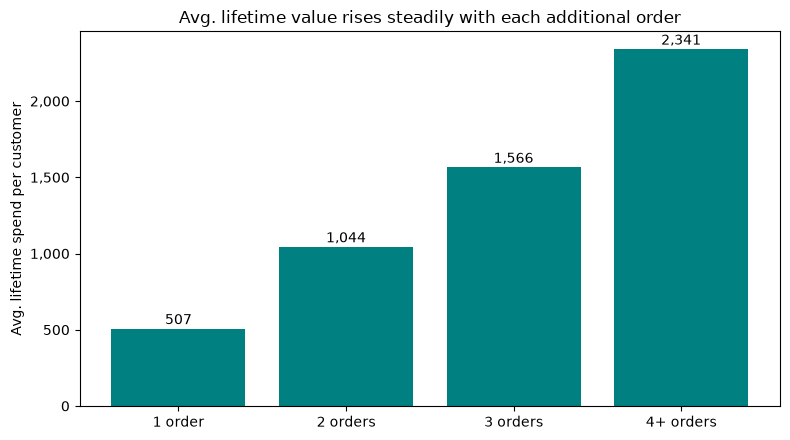

In [6]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(tier_order, tiers["avg_spend"], color="teal")
ax.yaxis.set_major_formatter(PLAIN)
ax.set_ylabel("Avg. lifetime spend per customer")
ax.set_title("Avg. lifetime value rises steadily with each additional order")
for i, v in enumerate(tiers["avg_spend"]):
    ax.text(i, v + 30, f"{v:,.0f}", ha="center")
fig.tight_layout()
plt.show()


**Conflict:** the relationship is clean and monotonic — a customer's 2nd order roughly doubles
their lifetime spend vs. a one-timer, and a 4th order roughly quadruples it. This looks like each
extra order adds a fairly consistent chunk of value, so the next question is *where* that value
comes from: are individual orders getting bigger as a customer sticks around, or is it purely a
volume effect (same size orders, just more of them)?


## 3. Does each order get bigger, or is it just more orders? (order-sequence growth)

For every order, compute its position in that customer's own order history (1st, 2nd, 3rd...).
Then compare the *average order value* at each position — this isolates whether the 2nd order a
customer places tends to be bigger than the 1st, independent of how many customers even reach a
2nd order.


In [7]:
df["order_seq"] = df.groupby("Customer_iD").cumcount() + 1

by_seq = df.groupby("order_seq").agg(
    n=("Order_ID", "size"),
    avg_value=("Total_amount_excl__VAT", "mean"),
    avg_profit=("Profit", "mean"),
)
by_seq["value_growth_%"] = by_seq["avg_value"].pct_change() * 100

by_seq_capped = by_seq[by_seq["n"] >= 100]
by_seq_capped.round(2)


,n,avg_value,avg_profit,value_growth_%
order_seq,,,,
1,577950,517.92,332.84,NaN
2,82041,472.77,302.49,-8.72
3,16375,465.78,297.61,-1.48
4,4212,460.08,295.62,-1.22
5,1257,457.16,293.47,-0.63
6,457,465.29,299.32,1.78
7,210,435.68,275.56,-6.36
8,100,534.78,339.87,22.75


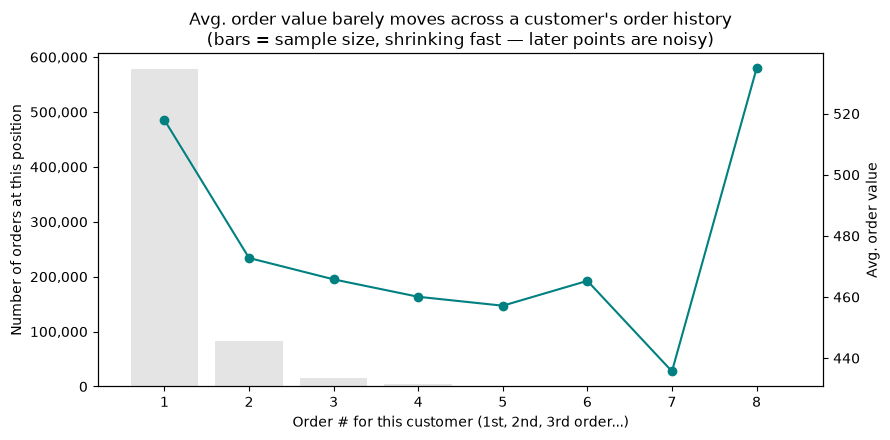

In [8]:
fig, ax1 = plt.subplots(figsize=(9, 4.5))
x = by_seq_capped.index

ax1.bar(x, by_seq_capped["n"], color="lightgray", alpha=0.6, label="# orders at this position (right axis n/a)")
ax1.set_ylabel("Number of orders at this position")
ax1.yaxis.set_major_formatter(PLAIN)

ax2 = ax1.twinx()
ax2.plot(x, by_seq_capped["avg_value"], marker="o", color="teal", label="Avg. order value")
ax2.yaxis.set_major_formatter(PLAIN)
ax2.set_ylabel("Avg. order value")

ax1.set_xlabel("Order # for this customer (1st, 2nd, 3rd order...)")
ax1.set_title("Avg. order value barely moves across a customer's order history\n(bars = sample size, shrinking fast — later points are noisy)")
fig.tight_layout()
plt.show()


**Conflict — this is the counter-intuitive part:** average order value does **not** grow with
order sequence. It actually drops ~9% from the 1st order to the 2nd, then stays roughly flat
(within noise) through the 3rd, 4th and 5th orders, before the sample size collapses (order counts
above ~6 are a few hundred customers or fewer, too thin to trust). So loyal customers are **not**
buying bigger baskets each time — the huge lifetime-value gap in section 2 comes entirely from
**order frequency**, not from orders growing in size. This matters for the recommendation: don't
expect a loyalty program to raise basket size — its lever is getting customers to come back at
all, not to spend more per visit.


## 4. How fast does the value gap open up? (cumulative value over time)

Since the per-order size doesn't grow, the loyal-customer premium must accumulate through
*time* and *frequency* instead. To see that directly, take customers whose first order was at
least 12 months before the last date in the data (so every customer has a full 12-month window
to observe), and track their **cumulative** spend and profit per customer, month by month since
their first order — comparing customers who turned out to be repeat buyers vs. one-time buyers.

Caveat: this splits customers by their *eventual* loyalty (known only in hindsight), so it shows
the size of the gap, not a causal effect of a loyalty program.


In [9]:
first_order_date = df.groupby("Customer_iD")["Order_Date"].transform("min")
df["months_since_first"] = ((df["Order_Date"] - first_order_date).dt.days / 30.44).astype(int)

max_date = df["Order_Date"].max()
observable = cust[cust["first_order"] <= max_date - pd.Timedelta(days=365)]
print(f"Customers with a full 12-month observation window: {len(observable):,} of {n_customers:,}")

d = df[df["Customer_iD"].isin(observable.index) & (df["months_since_first"] <= 12)].merge(
    observable["segment"], left_on="Customer_iD", right_index=True
)
seg_sizes = observable["segment"].value_counts()

monthly = d.groupby(["segment", "months_since_first"])[["Total_amount_excl__VAT", "Profit"]].sum()
monthly["spend_per_cust"] = monthly["Total_amount_excl__VAT"] / monthly.index.get_level_values("segment").map(seg_sizes)
monthly["profit_per_cust"] = monthly["Profit"] / monthly.index.get_level_values("segment").map(seg_sizes)

cum_spend = monthly["spend_per_cust"].unstack("segment").fillna(0).cumsum()
cum_profit = monthly["profit_per_cust"].unstack("segment").fillna(0).cumsum()
cum_spend.round(1)


Customers with a full 12-month observation window: 153,437 of 577,950


segment,One-time (1 order),Repeat (2+ orders)
months_since_first,,
0,446.5,635.3
1,446.5,678.8
2,446.5,710.9
3,446.5,735.1
4,446.5,759.7
5,446.5,786.3
6,446.5,813.5
7,446.5,839.2
8,446.5,864.2


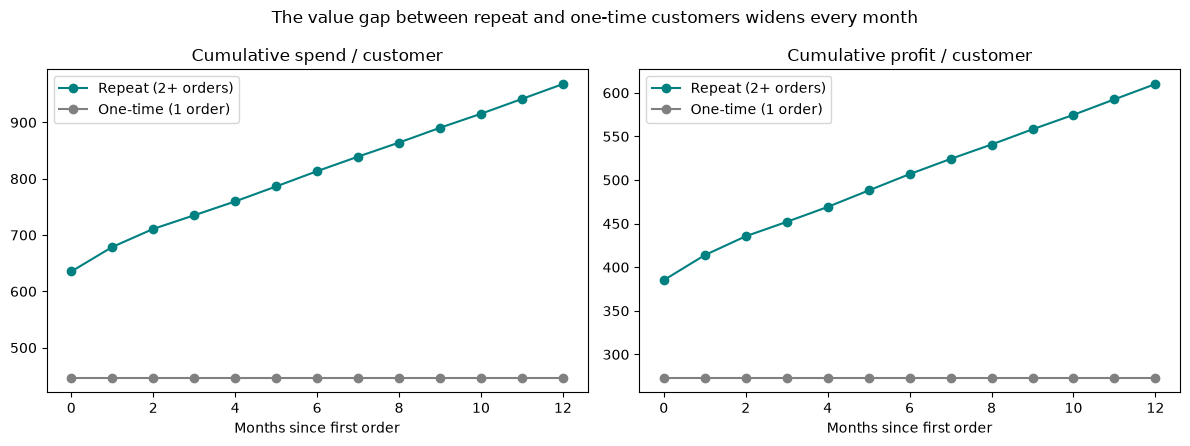

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, cum, title in zip(axes, [cum_spend, cum_profit], ["Cumulative spend / customer", "Cumulative profit / customer"]):
    ax.plot(cum.index, cum["Repeat (2+ orders)"], marker="o", color="teal", label="Repeat (2+ orders)")
    ax.plot(cum.index, cum["One-time (1 order)"], marker="o", color="gray", label="One-time (1 order)")
    ax.yaxis.set_major_formatter(PLAIN)
    ax.set_xlabel("Months since first order")
    ax.set_title(title)
    ax.legend()

fig.suptitle("The value gap between repeat and one-time customers widens every month")
fig.tight_layout()
plt.show()


In [11]:
ratio_spend_0 = cum_spend.loc[0, "Repeat (2+ orders)"] / cum_spend.loc[0, "One-time (1 order)"]
ratio_spend_12 = cum_spend.loc[12, "Repeat (2+ orders)"] / cum_spend.loc[12, "One-time (1 order)"]
ratio_profit_0 = cum_profit.loc[0, "Repeat (2+ orders)"] / cum_profit.loc[0, "One-time (1 order)"]
ratio_profit_12 = cum_profit.loc[12, "Repeat (2+ orders)"] / cum_profit.loc[12, "One-time (1 order)"]

print(f"Spend ratio  (Repeat / One-time) at month 0:  {ratio_spend_0:.2f}x")
print(f"Spend ratio  (Repeat / One-time) at month 12: {ratio_spend_12:.2f}x")
print(f"Profit ratio (Repeat / One-time) at month 0:  {ratio_profit_0:.2f}x")
print(f"Profit ratio (Repeat / One-time) at month 12: {ratio_profit_12:.2f}x")


Spend ratio  (Repeat / One-time) at month 0:  1.42x
Spend ratio  (Repeat / One-time) at month 12: 2.17x
Profit ratio (Repeat / One-time) at month 0:  1.41x
Profit ratio (Repeat / One-time) at month 12: 2.23x


**Conflict resolved:** even in the *first* order (month 0), customers who go on to become
repeat buyers already spend ~1.4x what one-time customers spend — a pre-existing difference, not
something loyalty creates. But the gap keeps widening every month after that: by month 12 it's
grown to ~2.2x on both spend and profit. So loyalty **compounds** value on top of an initial
difference, growing roughly linearly over the first year rather than plateauing.


## Summary

**Setup:** does customer loyalty (repeat purchasing) actually correlate with higher value, and if
so, how much more valuable are loyal customers and how fast does that value build up?

**Conflict / resolution:**

- **Loyalty is rare but valuable:** only 14.2% of customers ever place a 2nd order, but they
  generate ~28% of revenue and ~28% of profit — roughly 2x their share of the customer base.
- **It's monotonic, not a step change:** avg. lifetime spend rises steadily with order count —
  roughly 507 (1 order) → 1,044 (2 orders) → 1,566 (3 orders) → 2,341 (4+ orders) — each extra
  order adds a consistent, large chunk of value.
- **The surprise: it's not bigger baskets.** Average order *value* does not grow across a
  customer's order history — it dips ~9% from order 1 to order 2 and then stays flat. The entire
  lifetime-value premium comes from **frequency** (more orders), not from customers spending more
  per order as they stick around.
- **The gap compounds over time:** customers who turn out to be repeat buyers already spend ~1.4x
  more on their very first order, but by 12 months after that first order the gap has grown to
  ~2.2x on both spend and profit — the premium builds up steadily rather than being fixed at
  acquisition.

**So what:** loyal customers are unambiguously more valuable, but the lever is getting people to
come back, not getting them to spend more per visit. A loyalty program should target repeat
*frequency* (e.g. incentives for a 2nd/3rd order, similar to the free-shipping conversion idea in
`Q1.1`) rather than upsell/basket-size tactics, since basket size doesn't budge with tenure.
